In [1]:
# Import polars and set configurations

import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# General for every plot

# Columns 
columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "DeltaPSI",
    "Raw P-Val",
    "rMATS Event ID"
]

# Plot colors

def assign_color(row):
    if row["FDR"] > 0.05 or abs(row["DeltaPSI"]) < 0.05:
        return "gray"
    elif row["DeltaPSI"] >= 0.05:
        return "red"
    elif row["DeltaPSI"] <= -0.05:
        return "blue"
    else:
        return "gray"

In [6]:
# Function to get path for big table

from pathlib import Path

def get_path(cell_line: str, path_file: str = "data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

In [8]:
# Read in data for both cell lines

data_path_K562 = get_path("HepG2")
K562 = pl.read_ipc(data_path_K562)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [9]:
# Read in data for both cell lines

data_path_HepG2 = get_path("HepG2")
HEPG2 = pl.read_ipc(data_path_HepG2)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


# Volcano Plot for RBFOX2 bound at pos 4 K562

RBFOX2
[4]


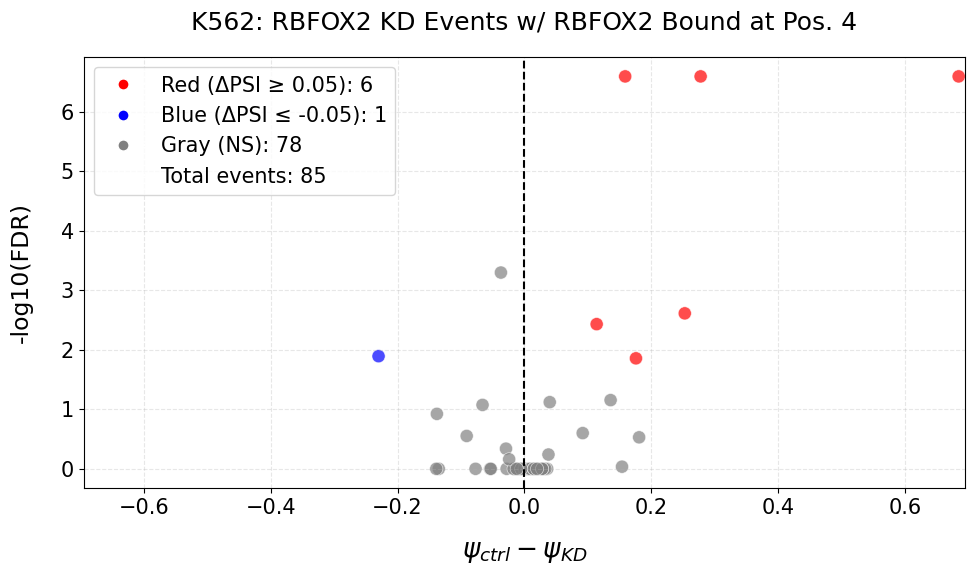

In [17]:
# K562

rbps = ["RBFOX2"]
positions = [4]

for rbp, position in zip(rbps, positions):
    
    print(rbp)
    print(positions)
    
    filtered_K562 = (
    K562
    .filter(
        (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{position}") == True)
    )
    .unique(subset=["rMATS Event ID"]))
    
    # Filter for needed columns
    filtered_K562 = filtered_K562.select(columns_to_keep)
    
    # Convert to pandas
    df = filtered_K562.to_pandas()
    
    # Prevents error for no data (SAFB or IGF..1)
    data = df["DeltaPSI"]

    if data.empty:
        continue 
    
    # DPSI conversion
    df["DeltaPSI"] = df["DeltaPSI"] * -1
    
    # -log10 FDR conversion
    
    # Find the smallest non-zero FDR value
    min_nonzero_fdr = df.loc[df["FDR"] > 0, "FDR"].min()
    
    # Replace zeros with min
    df["FDR_safe"] = df["FDR"].replace(0, min_nonzero_fdr)

    # Calculate -log10(FDR)
    df["neg_log10_FDR"] = -np.log10(df["FDR_safe"])
    
    # Colors and plots
    
    df["color"] = df.apply(assign_color, axis=1)

    counts = df["color"].value_counts().to_dict()
    num_points = len(df)
    
    # Parameter for global font size
    plt.rcParams.update({'font.size': 15})
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        df["DeltaPSI"],
        df["neg_log10_FDR"],
        c=df["color"],
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5,
        s = 90
    )
    
    # Setting x axis
    xlim = max(abs(min(df["DeltaPSI"])), abs(max(df["DeltaPSI"])))
    plt.xlim(-xlim - 0.01, xlim + 0.01)  # symmetric around zero
    plt.axvline(0, color="black", linestyle="--")  # reference line at zero

    # Legend
    legend_labels = [
        f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
        f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
        f"Gray (NS): {counts.get('gray', 0)}",
        f"Total events: {num_points}"
    ]

    # Create dummy handles for legend colors
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
               markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
               markerfacecolor='blue', markersize=8),
        Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
               markerfacecolor='gray', markersize=8),
        Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
    ]

    plt.legend(handles=handles, loc="best")

    # Labels
    plt.xlabel("$\\psi_{ctrl} - \\psi_{KD}$", fontsize = 19, labelpad = 15)
    plt.ylabel("-log10(FDR)", fontsize = 17, labelpad = 20)
    plt.title(f"K562: {rbp} KD Events w/ {rbp} Bound at Pos. {position}", pad=20)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Volcano Plot for RBFOX2 bound at pos 4 and not pos 3

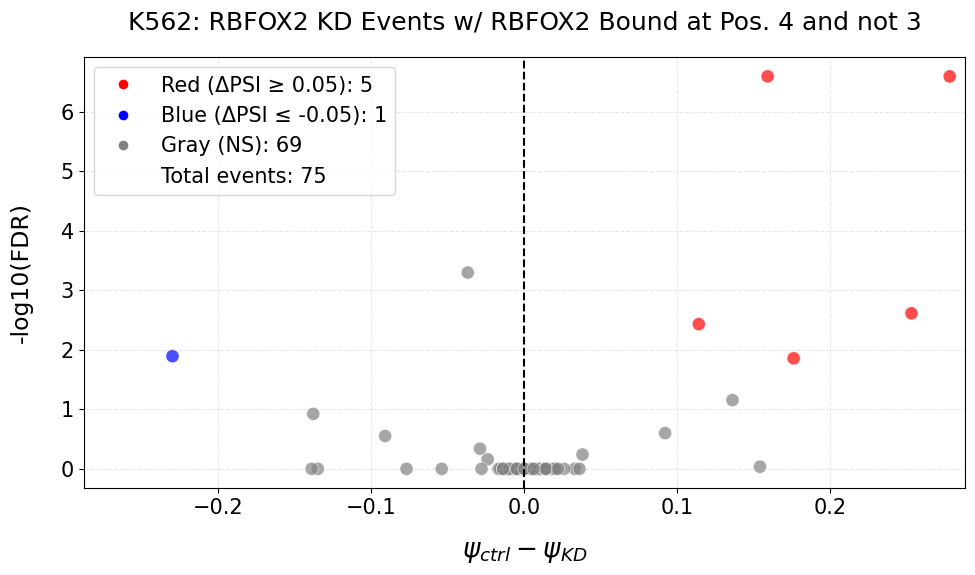

In [22]:
# K562

more_filtered_K562 = (
K562
.filter(
    (pl.col("RBP_KD_Target") == "RBFOX2")
    & (pl.col("has_RBP_KD_4"))
    & (~pl.col("has_RBP_KD_3"))
)
.unique(subset=["rMATS Event ID"])
)

# Filter for needed columns
filtered_K562 = more_filtered_K562.select(columns_to_keep)

# Convert to pandas
df = filtered_K562.to_pandas()

# Prevents error for no data (SAFB or IGF..1)
data = df["DeltaPSI"]

# if data.empty:
#    continue 

# DPSI conversion
df["DeltaPSI"] = df["DeltaPSI"] * -1

# -log10 FDR conversion
# Find the smallest non-zero FDR value
min_nonzero_fdr = df.loc[df["FDR"] > 0, "FDR"].min()

# Replace zeros with min
df["FDR_safe"] = df["FDR"].replace(0, min_nonzero_fdr)

# Calculate -log10(FDR)
df["neg_log10_FDR"] = -np.log10(df["FDR_safe"])

# Colors and plots

df["color"] = df.apply(assign_color, axis=1)

counts = df["color"].value_counts().to_dict()
num_points = len(df)

# Parameter for global font size
plt.rcParams.update({'font.size': 15})

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df["DeltaPSI"],
    df["neg_log10_FDR"],
    c=df["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5,
    s = 90
)

# Setting x axis
xlim = max(abs(min(df["DeltaPSI"])), abs(max(df["DeltaPSI"])))
plt.xlim(-xlim - 0.01, xlim + 0.01)  # symmetric around zero
plt.axvline(0, color="black", linestyle="--")  # reference line at zero

# Legend
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="best")

# Labels
plt.xlabel("$\\psi_{ctrl} - \\psi_{KD}$", fontsize = 19, labelpad = 15)
plt.ylabel("-log10(FDR)", fontsize = 17, labelpad = 20)
plt.title(f"K562: RBFOX2 KD Events w/ RBFOX2 Bound at Pos. 4 and not 3", pad=20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Volcano Plot for RBFOX2 KD events where RBFOX2 is bound at pos 4 HepG2

RBFOX2
[4]


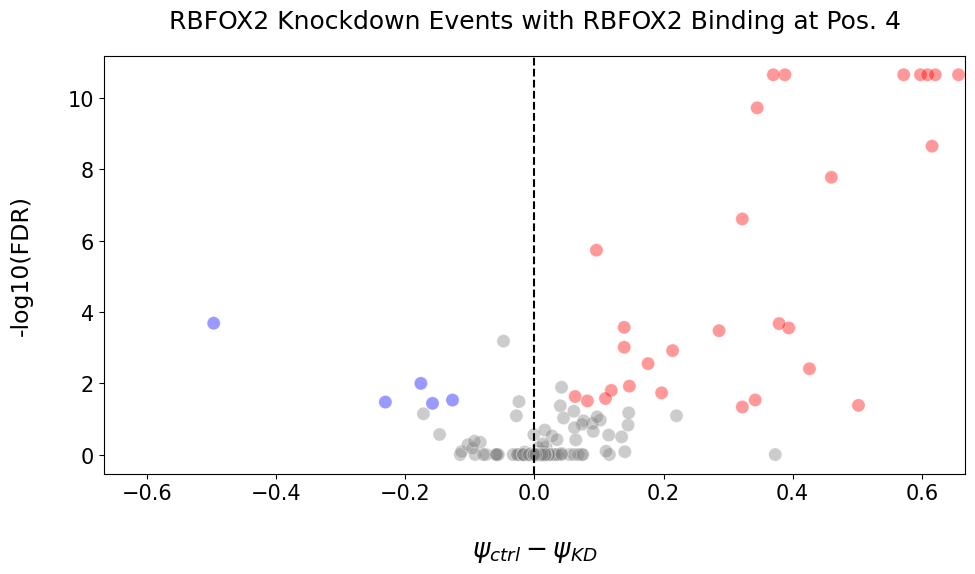

In [14]:
# HepG2

rbps = ["RBFOX2"]
positions = [4]

for rbp, position in zip(rbps, positions):
    
    print(rbp)
    print(positions)
    
    filtered_HepG2 = (
    HEPG2
    .filter(
        (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{position}") == True)
    )
    .unique(subset=["rMATS Event ID"]))
    
    # Filter for needed columns
    filtered_HepG2 = filtered_HepG2.select(columns_to_keep)
    
    # Convert to pandas
    df = filtered_HepG2.to_pandas()
    
    # Prevents error for no data (SAFB or IGF..1)
    data = df["DeltaPSI"]

    if data.empty:
        continue 
    
    # DPSI conversion
    df["DeltaPSI"] = df["DeltaPSI"] * -1
    
    # -log10 FDR conversion
    
    # Find the smallest non-zero FDR value
    min_nonzero_fdr = df.loc[df["FDR"] > 0, "FDR"].min()
    
    # Replace zeros with min
    df["FDR_safe"] = df["FDR"].replace(0, min_nonzero_fdr)

    # Calculate -log10(FDR)
    df["neg_log10_FDR"] = -np.log10(df["FDR_safe"])
    
    # Colors and plots
    
    df["color"] = df.apply(assign_color, axis=1)

    counts = df["color"].value_counts().to_dict()
    num_points = len(df)

    # Parameter for global font size
    plt.rcParams.update({'font.size': 15})
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        df["DeltaPSI"],
        df["neg_log10_FDR"],
        c=df["color"],
        alpha=0.4,
        edgecolors='w',
        linewidth=0.5,
        s=90
    )
    
    # Setting x axis
    xlim = max(abs(min(df["DeltaPSI"])), abs(max(df["DeltaPSI"])))
    plt.xlim(-xlim - 0.01, xlim + 0.01)  # symmetric around zero
    plt.axvline(0, color="black", linestyle="--")  # reference line at zero
    
    # Legend
    legend_labels = [
        f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
        f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
        f"Gray (NS): {counts.get('gray', 0)}",
        f"Total events: {num_points}"
    ]
    
    # Labels
    plt.xlabel("$\\psi_{ctrl} - \\psi_{KD}$", fontsize=19, labelpad=25)
    plt.ylabel("-log10(FDR)", fontsize=17, labelpad=25)
    plt.title(f"{rbp} Knockdown Events with {rbp} Binding at Pos. {position}", pad=20)
    plt.tight_layout()
    plt.show()

## Volcano plot for RBFOX2 KD events where RBFOX2 is bound at pos 4 not 3 HepG2

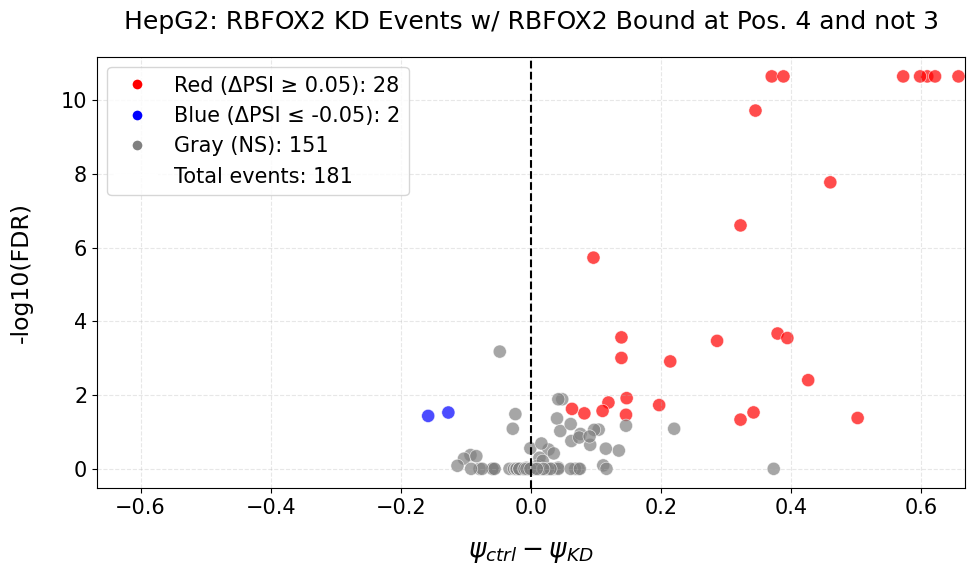

In [7]:
more_filtered_HepG2 = (
HEPG2
.filter(
    (pl.col("RBP_KD_Target") == "RBFOX2")
    & (pl.col("has_RBP_KD_4"))
    & (~pl.col("has_RBP_KD_3"))
)
.unique(subset=["rMATS Event ID"])
)

# Filter for needed columns
filtered_HepG2 = more_filtered_HepG2.select(columns_to_keep)

# Convert to pandas
df = filtered_HepG2.to_pandas()

# Prevents error for no data (SAFB or IGF..1)
data = df["DeltaPSI"]

# if data.empty:
#    continue 

# DPSI conversion
df["DeltaPSI"] = df["DeltaPSI"] * -1

# -log10 FDR conversion
# Find the smallest non-zero FDR value
min_nonzero_fdr = df.loc[df["FDR"] > 0, "FDR"].min()

# Replace zeros with min
df["FDR_safe"] = df["FDR"].replace(0, min_nonzero_fdr)

# Calculate -log10(FDR)
df["neg_log10_FDR"] = -np.log10(df["FDR_safe"])

# Colors and plots

df["color"] = df.apply(assign_color, axis=1)

counts = df["color"].value_counts().to_dict()
num_points = len(df)

# Parameter for global font size
plt.rcParams.update({'font.size': 15})

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df["DeltaPSI"],
    df["neg_log10_FDR"],
    c=df["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5,
    s = 90
)

# Setting x axis
xlim = max(abs(min(df["DeltaPSI"])), abs(max(df["DeltaPSI"])))
plt.xlim(-xlim - 0.01, xlim + 0.01)  # symmetric around zero
plt.axvline(0, color="black", linestyle="--")  # reference line at zero

# Legend
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="best")

# Labels
plt.xlabel("$\\psi_{ctrl} - \\psi_{KD}$", fontsize = 19, labelpad = 15)
plt.ylabel("-log10(FDR)", fontsize = 17, labelpad = 20)
plt.title(f"HepG2: RBFOX2 KD Events w/ RBFOX2 Bound at Pos. 4 and not 3", pad=20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()